In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from skimage import measure, morphology
import rasterio
import seaborn as sns
from src.classification import run_classification_workflow
from src.basic_statistics import run_statistics_workflow
from src.segmentation import run_segmentation_workflow
from src.classification2 import combined_segmentation_classification_workflow

In [2]:
path = "/Users/devseed/Documents/repos/OBIA_workflow/data/Sentinel2A_subset_bands_ToA_BGRNirSWIR1SWIR2.tif"

Loading Sentinel-2 image...
Image loaded: (1288, 1320)
Calculating spectral indices...
Performing K-means segmentation with 6 clusters...


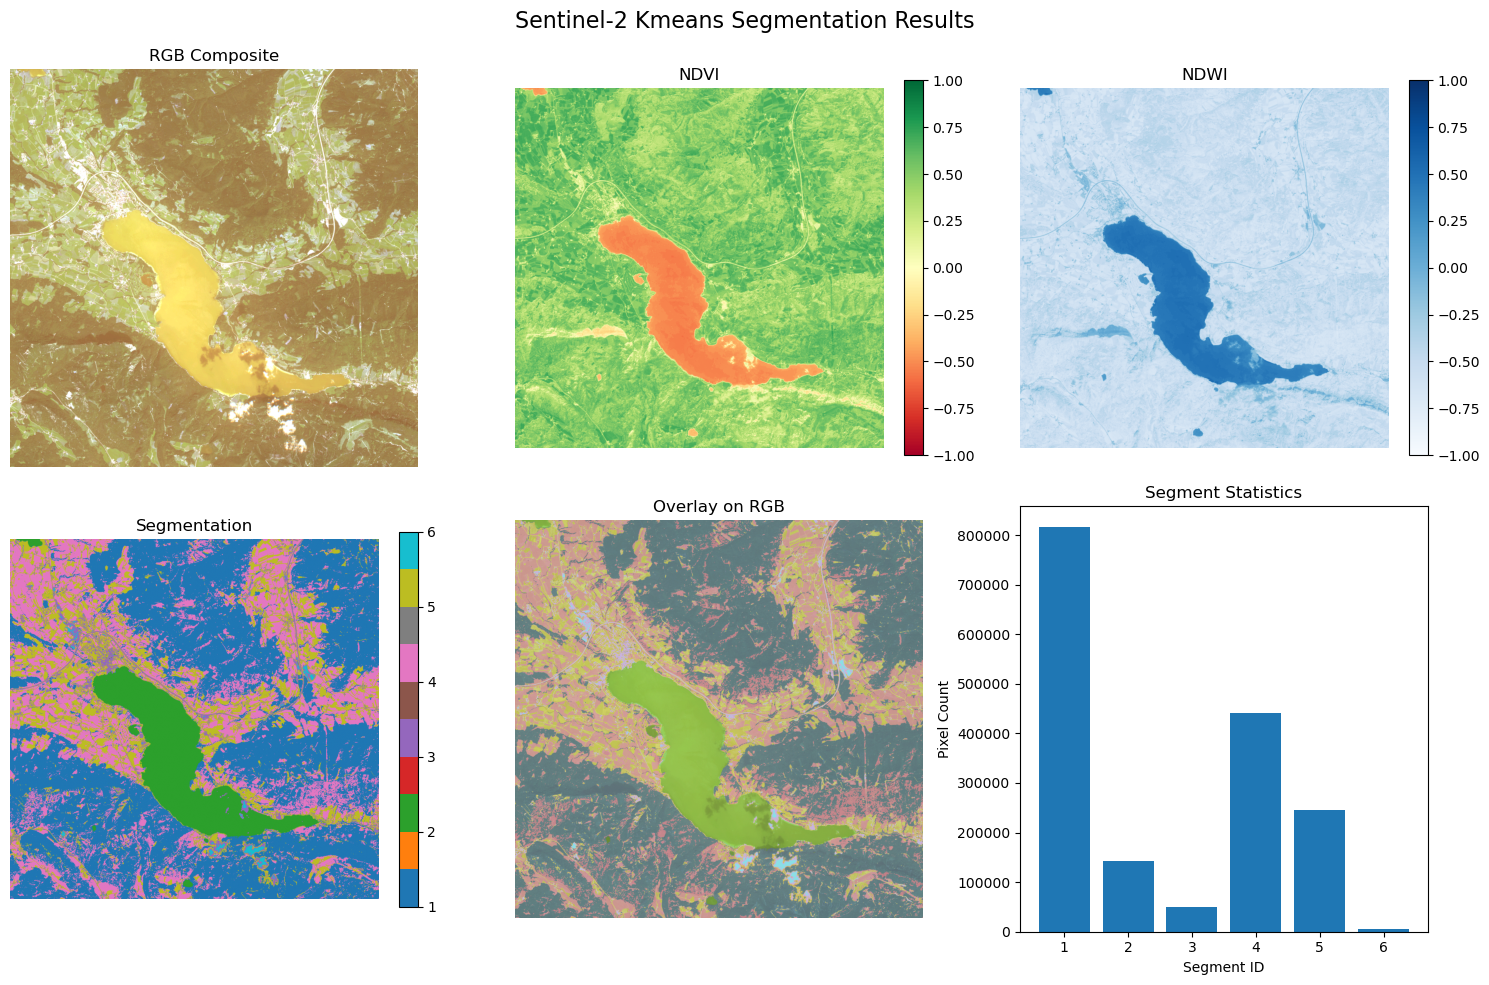


Segmentation Statistics:
segment_1: 816915 pixels, NDVI: 0.411, NDWI: -0.490
segment_2: 142798 pixels, NDVI: -0.484, NDWI: 0.435
segment_3: 49141 pixels, NDVI: 0.266, NDWI: -0.273
segment_4: 440937 pixels, NDVI: 0.610, NDWI: -0.621
segment_5: 244865 pixels, NDVI: 0.474, NDWI: -0.479
segment_6: 5504 pixels, NDVI: 0.176, NDWI: -0.162


In [7]:
segments = run_segmentation_workflow(path, method='kmeans')[2]

Loading image for statistics...
Extracting objects...
Found 6 objects
Calculating spectral statistics...
Calculating geometric statistics...
Calculating texture statistics...
Merging all statistics...
Statistics calculated for 6 objects


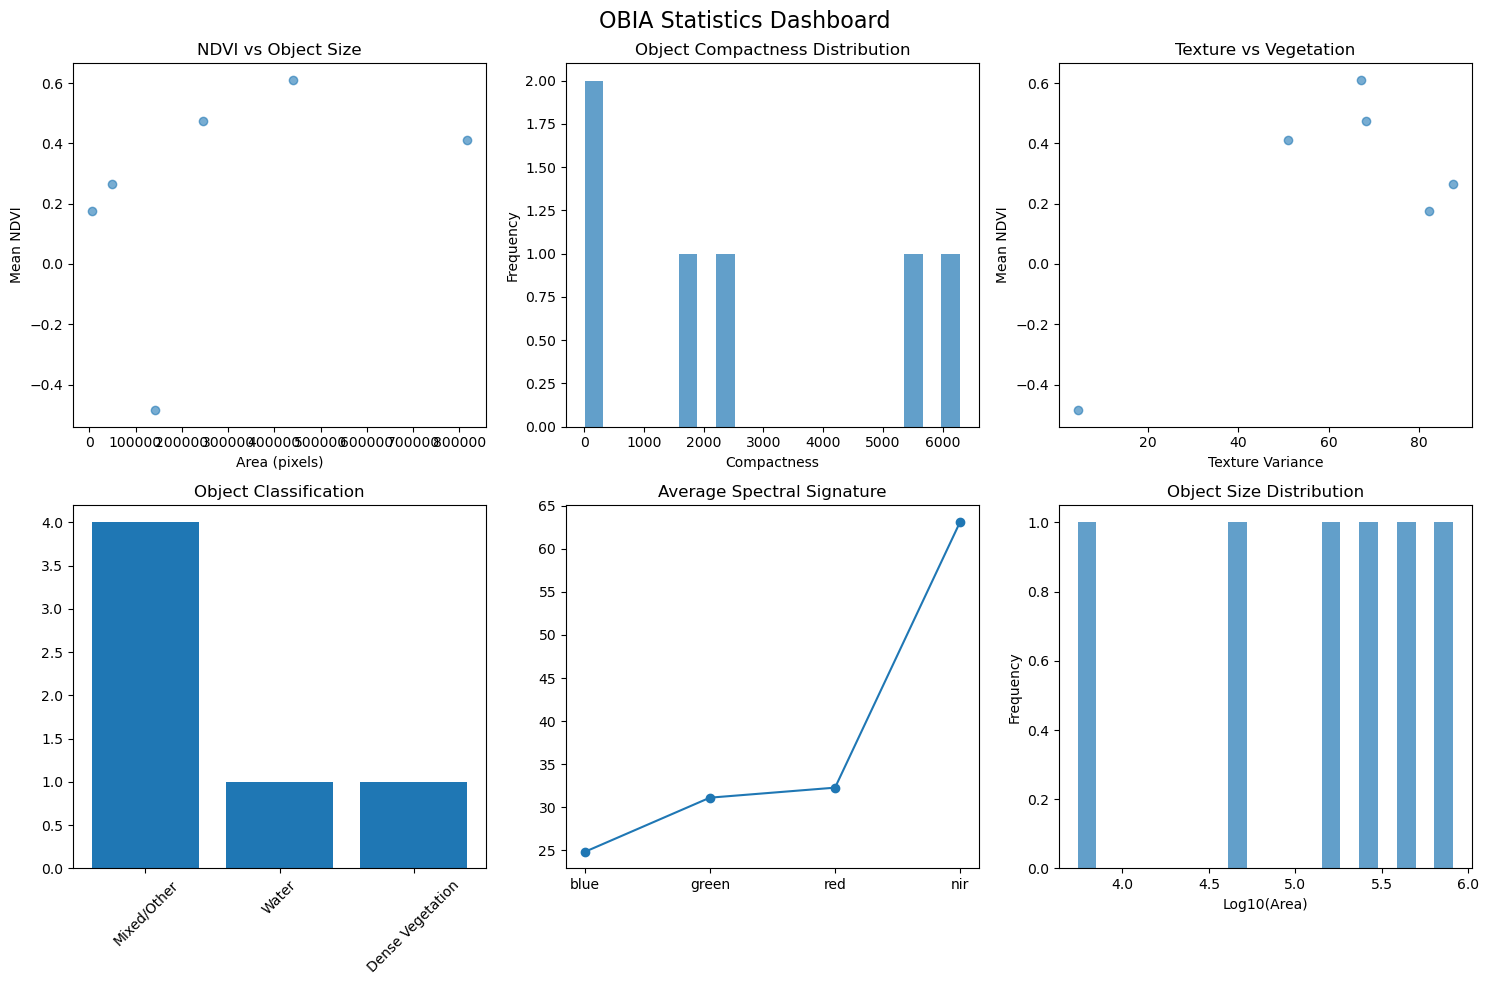


=== OBIA STATISTICS SUMMARY ===
Total objects analyzed: 6
Total area covered: 1700160.0 pixels
Average object size: 283360.0 pixels
Size range: 5504.0 - 816915.0 pixels

Spectral Statistics:
Mean NDVI: 0.242 ± 0.387
Mean NDWI: -0.265 ± 0.381

Classification Results:
  Mixed/Other: 4 objects (66.7%)
  Water: 1 objects (16.7%)
  Dense Vegetation: 1 objects (16.7%)


In [8]:
stats_df = run_statistics_workflow(path, segments=segments)[0]

In [9]:
run_classification_workflow(path, segments=segments, stats_df=stats_df)

Preparing features...
Creating training labels...
Training samples per class:
labels
Mixed    3
Water    1
Name: count, dtype: int64
Training Random Forest...


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

Segmentation workflow not available. Running pixel-based classification only.
Loading Sentinel-2 image for classification...
Image loaded: (1288, 1320)
Calculating spectral indices for classification...
Performing rule-based classification...
Post-processing classification...
Calculating classification statistics...
Classification unique values: [0 1 2 4]
Classification shape: (1288, 1320)
Classification dtype: uint8


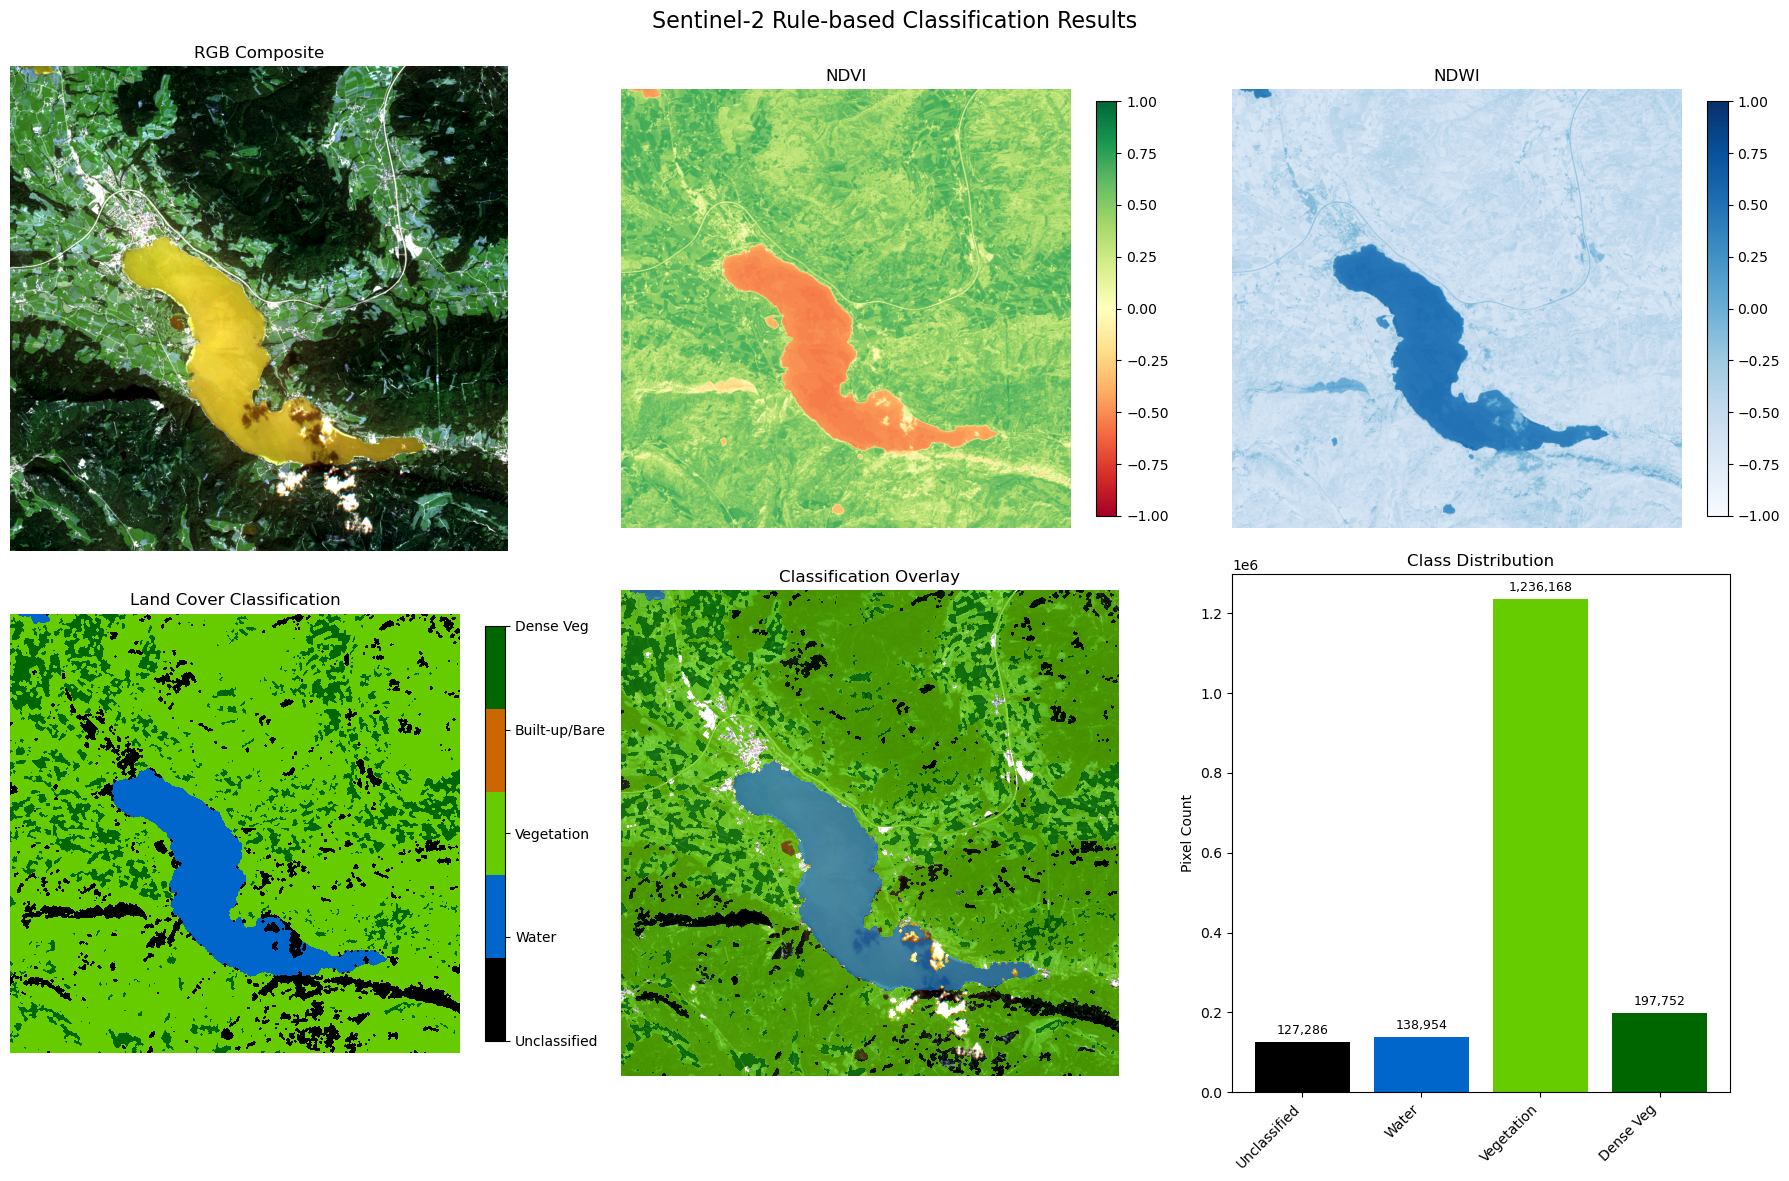

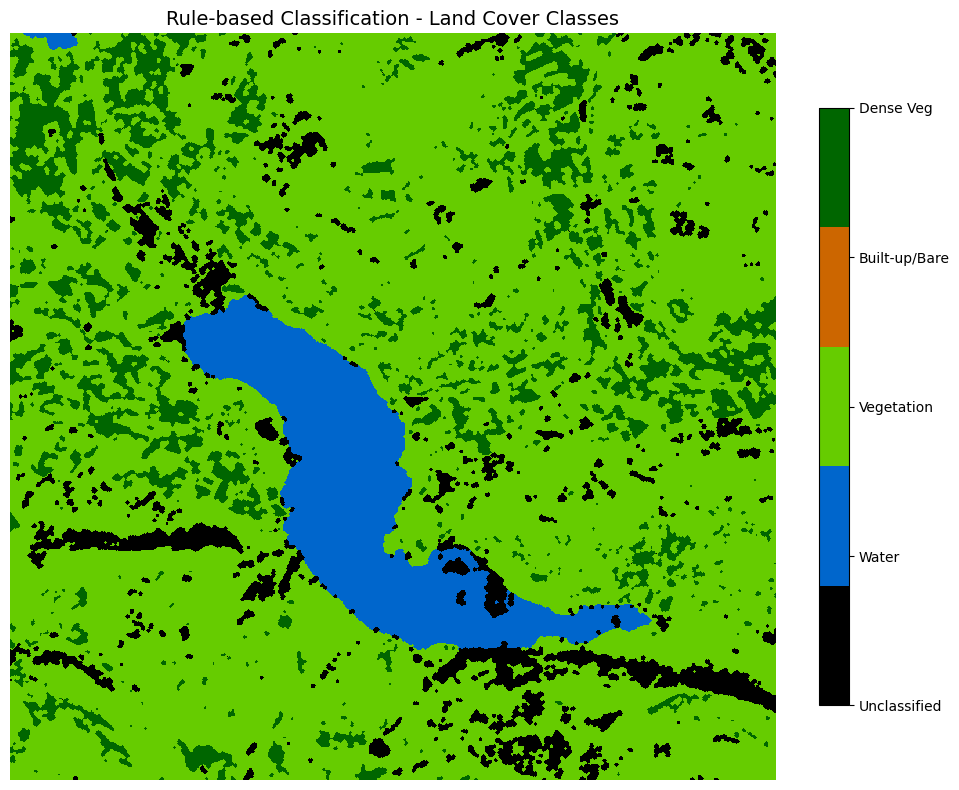


LAND COVER CLASSIFICATION REPORT

Unclassified:
  Pixels: 127,286
  Percentage: 7.49%
  Area: 12.73 km²

Water:
  Pixels: 138,954
  Percentage: 8.17%
  Area: 13.90 km²

Vegetation:
  Pixels: 1,236,168
  Percentage: 72.71%
  Area: 123.62 km²

Dense Vegetation:
  Pixels: 197,752
  Percentage: 11.63%
  Area: 19.78 km²

Total mapped area: 170.02 km²
Assessing classification quality...

Quality Assessment:
  Water classification accuracy: 98.7%
  Vegetation classification accuracy: 99.1%
  Classification coverage: 92.5%


(array([[2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        ...,
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2]], shape=(1288, 1320), dtype=uint8),
 {'Unclassified': {'pixels': 127286,
   'percentage': np.float64(7.486707133446265),
   'area_km2': np.float64(12.7286)},
  'Water': {'pixels': 138954,
   'percentage': np.float64(8.172995482778092),
   'area_km2': np.float64(13.8954)},
  'Vegetation': {'pixels': 1236168,
   'percentage': np.float64(72.70892151326935),
   'area_km2': np.float64(123.6168)},
  'Dense Vegetation': {'pixels': 197752,
   'percentage': np.float64(11.631375870506306),
   'area_km2': np.float64(19.7752)}},
 {'Water classification accuracy': '98.7%',
  'Vegetation classification accuracy': '99.1%',
  'Classification coverage': '92.5%'})

In [3]:
combined_segmentation_classification_workflow(path, segmentation_method='kmeans')